# 1. Data Loading

In [12]:
# 1. Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("trainDataSet.csv", sep=';')

print("Veri başarıyla yüklendi")
print(df.head())

Veri başarıyla yüklendi
   Month  DayOfWeek  FlightDate Operating_Airline  \
0      1          3  2023-01-04                AS   
1      1          7  2023-01-29                G7   
2      1          2  2023-01-10                AA   
3      1          2  2023-01-03                UA   
4      1          4  2023-01-12                AA   

   Flight_Number_Operating_Airline  OriginAirportID Origin    OriginCityName  \
0                              435            14747    SEA       Seattle, WA   
1                             4445            12264    IAD    Washington, DC   
2                             2373            14262    PSP  Palm Springs, CA   
3                             2336            12264    IAD    Washington, DC   
4                             2461            14107    PHX       Phoenix, AZ   

   DestAirportID Dest  ... Diverted  CRSElapsedTime  ActualElapsedTime  \
0          14771  SFO  ...        0             135                170   
1          14685  SAV  ...  

# 2. Data Exploration

In [13]:
# 2. Data Exploration

print("Kolonlar:")
print(df.columns)

print("\nVeri tipleri:")
print(df.dtypes)

print("\nEksik veri sayısı:")
print(df.isnull().sum())

Kolonlar:
Index(['Month', 'DayOfWeek', 'FlightDate', 'Operating_Airline',
       'Flight_Number_Operating_Airline', 'OriginAirportID', 'Origin',
       'OriginCityName', 'DestAirportID', 'Dest', 'DestCityName', 'CRSDepTime',
       'DepTime', 'DepDelayMinutes', 'DepDel15', 'CRSArrTime', 'ArrTime',
       'ArrDelayMinutes', 'ArrDel15', 'Cancelled', 'CancellationCode',
       'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay'],
      dtype='str')

Veri tipleri:
Month                              int64
DayOfWeek                          int64
FlightDate                           str
Operating_Airline                    str
Flight_Number_Operating_Airline    int64
OriginAirportID                    int64
Origin                               str
OriginCityName                       str
DestAirportID                      int64
Dest                                 str
DestCity

# 3. Target ve Feature Seçimi

In [14]:
# 3. Feature ve Target seçimi

features = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'LateAircraftDelay']
target = 'ArrDelayMinutes'

X = df[features]
y = df[target]

# 4. Eksik Verileri Temizleme

In [15]:
# 4. Eksik verileri temizleme

X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data[features]
y = data[target]

print("Temizlenmiş veri boyutu:", data.shape)

Temizlenmiş veri boyutu: (93240, 5)


# 5. Multiple Linear Regression

In [16]:
# 5. Model Training

model = LinearRegression()

model.fit(X, y)

print("Model eğitildi")

Model eğitildi


# 6. Model Katsayılarını İnceleme

In [17]:
# 6. Model coefficients

coefficients = pd.DataFrame(model.coef_, features, columns=['Coefficient'])

print(coefficients)

                   Coefficient
CarrierDelay          0.996824
WeatherDelay          0.997552
NASDelay              0.996151
LateAircraftDelay     0.998246


# 7. Tahmin Yapma

In [18]:
# 7. Prediction

y_pred = model.predict(X)

print("Tahminler oluşturuldu")

Tahminler oluşturuldu


# 8. Görselleştirme

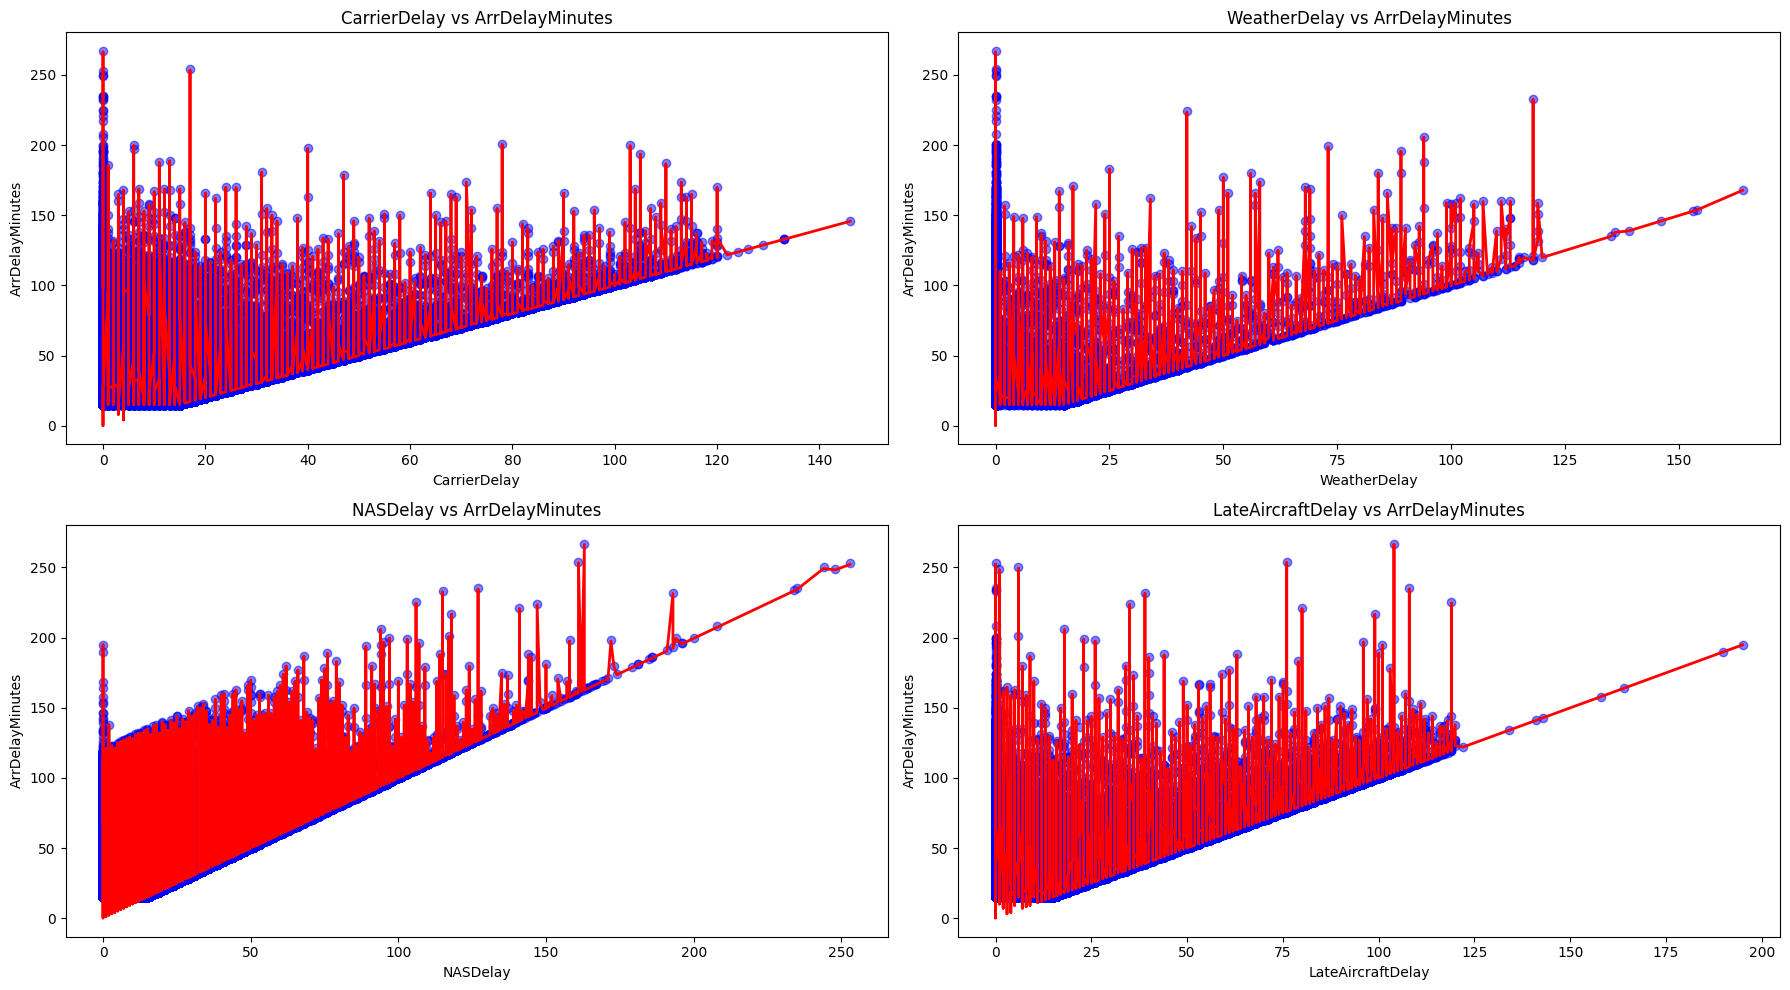

In [19]:
plt.figure(figsize=(18,10))

for i, feature in enumerate(features):
    
    plt.subplot(2, 2, i+1)
    
    # scatter plot (gerçek veri)
    plt.scatter(X[feature], y, color='blue', alpha=0.5)
    
    # regresyon çizgisi için sıralama
    sorted_index = X[feature].argsort()
    
    plt.plot(X[feature].iloc[sorted_index],
             y_pred[sorted_index],
             color='red',
             linewidth=2)
    
    plt.xlabel(feature)
    plt.ylabel("ArrDelayMinutes")
    plt.title(f"{feature} vs ArrDelayMinutes")

plt.tight_layout()
plt.show()

# only red line

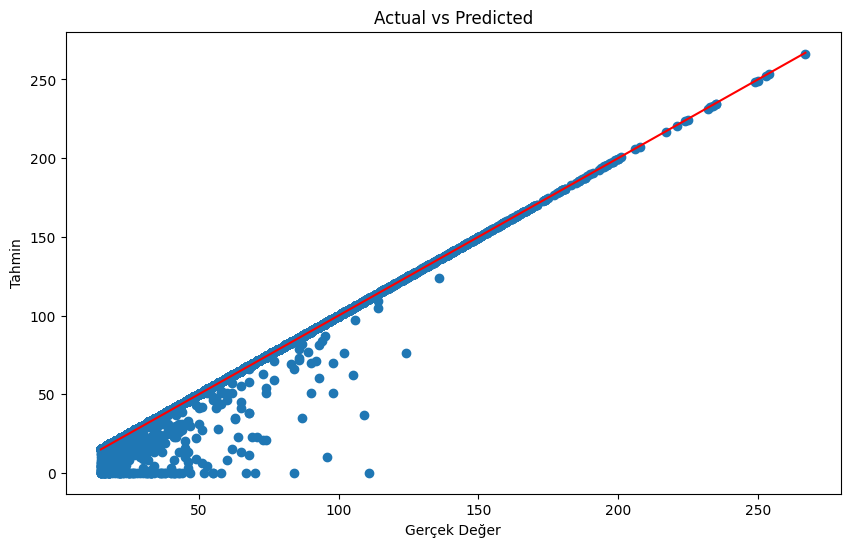

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(y, y_pred)

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')

plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin")

plt.title("Actual vs Predicted")

plt.show()

model_analiz

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Train verisi üzerinden tahmin 
y_pred = model.predict(X)

# 2. Metrik hesaplamaları
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("--- EĞİTİM (TRAIN) VERİSİ PERFORMANS SONUÇLARI ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R2 Score): {r2:.4f}")

--- EĞİTİM (TRAIN) VERİSİ PERFORMANS SONUÇLARI ---
Mean Absolute Error (MAE): 0.1720
Root Mean Squared Error (RMSE): 1.5046
R-Squared (R2 Score): 0.9960
